/home/h_wu4/ml_env/lib/python3.8/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Sample parameter grid entries:
  Entry 1: {'sampler': ['passthrough'], 'classifier': [GaussianNB()], 'classifier__var_smoothing': array([1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07])}
  Entry 2: {'sampler': [RandomOverSampler(), SMOTE(), ADASYN()], 'sampler__sampling_strategy': [0.5, 1.0, 1.5], 'classifier': [GaussianNB()], 'classifier__var_smoothing': array([1.e-12, 1.e-11, 1.e-10, 1.e-09, 1.e-08, 1.e-07])}
  Entry 3: {'sampler': ['passthrough'], 'classifier': [MultinomialNB()], 'classifier__alpha': array([  1.  ,  25.75,  50.5 ,  75.25, 100.  ]), 'classifier__fit_prior': [True, False], 'classifier__force_alpha': [True]}
Starting Grid Search...


Grid Search Progress:   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
5080 fits failed out of a total of 7600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
106 fits failed with the following error:
Traceback (most recent call last):
  File "/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/h_wu4/ml_env/lib/python3.8/site-packages/sklearn/base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/h_wu4/ml_env/lib/python3.8/site-packages/imblearn/pipeline.py", line 329, in fit
    Xt, yt = self._fit(X, y, routed_params)
  File "/home

Grid Search Completed.

Best Average AUC: 0.6977 ± 0.0444
Average Accuracy: 0.6790 ± 0.0257
Average Precision: 0.1623 ± 0.0240
Average F1 Score: 0.2553 ± 0.0357

Best Hyperparameters:
  classifier: BernoulliNB()
  classifier__alpha: 25.75
  classifier__binarize: 0.0
  classifier__fit_prior: False
  classifier__force_alpha: True
  sampler: RandomOverSampler()
  sampler__sampling_strategy: 0.5

Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.2857, Accuracy=0.8546, Precision=0.2609
  Fold 2: F1=0.2400, Accuracy=0.8463, Precision=0.2174
  Fold 3: F1=0.2883, Accuracy=0.8722, Precision=0.2909
  Fold 4: F1=0.2794, Accuracy=0.8414, Precision=0.2375
  Fold 5: F1=0.2124, Accuracy=0.8560, Precision=0.2105
  Fold 6: F1=0.2000, Accuracy=0.8188, Precision=0.1667
  Fold 7: F1=0.3932, Accuracy=0.8851, Precision=0.3770
  Fold 8: F1=0.3333, Accuracy=0.8706, Precision=0.3175
  F

Grid Search Progress:   0%|          | 0/100 [02:55<?, ?it/s]


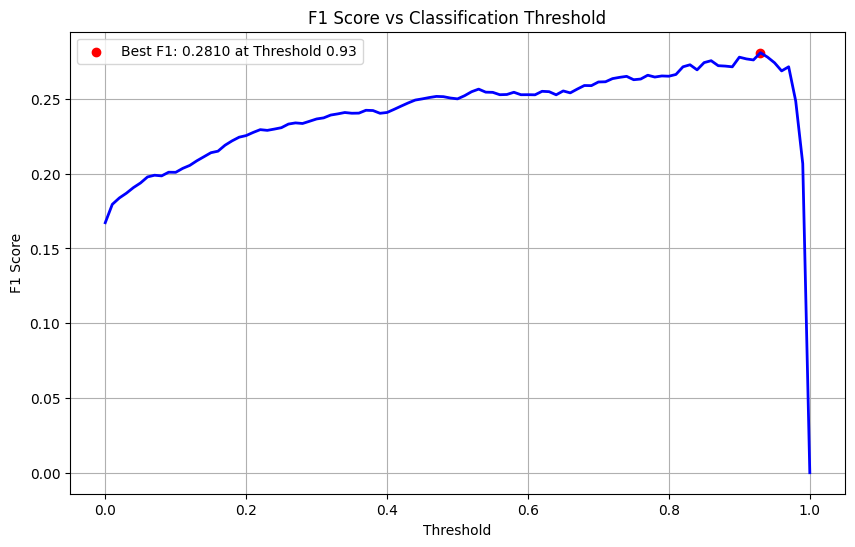

In [1]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB, CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline  # Use ImbPipeline from imblearn to handle oversampling
from itertools import chain
from sklearn.exceptions import UndefinedMetricWarning

# Suppress specific warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class123_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [28, 234, 36, 215, 189, 37, 77, 26, 250, 188, 236, 181, 70, 55, 48, 67, 202, 244, 78, 65, 52, 237, 211, 57, 185, 229, 231, 219, 62, 220, 51, 200, 30, 242, 233, 198, 34, 25, 212, 205, 252, 32, 29, 248, 253, 75, 66, 247, 56, 58, 12, 221, 41, 197, 7, 63, 217, 1, 251, 199, 114, 49, 24, 50, 101, 80, 186, 232, 207, 130, 79, 115, 43, 243, 190, 137, 136, 108, 46, 214, 17, 10, 110, 88, 125, 182, 33, 203, 225, 68, 213, 227, 126, 93, 81, 14, 13, 104, 92, 42, 201, 129, 177, 122, 134, 133, 60, 19, 31, 9, 135, 98, 8, 45, 3, 47, 4, 6, 226, 116, 106, 90, 15, 105, 138, 18, 89, 84, 100, 44, 228, 131, 38, 112, 103, 96, 16, 127, 206, 117, 11, 102, 176, 128, 97, 0, 132, 5, 256, 61, 235, 87, 91, 193, 39]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Define a pipeline with optional scaling, oversampling, and classifier
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),  # You can change this to MinMaxScaler or remove it if not needed
    ('sampler', RandomOverSampler()),  # Oversampling step
    ('classifier', GaussianNB())
])

# Define a helper function to create parameter grids for each classifier
def create_param_grids(classifier_params, force_alpha=False):
    grids = []
    # Grid where sampler is 'passthrough'
    grid_passthrough = {
        'sampler': ['passthrough'],
        **classifier_params
    }
    if force_alpha:
        grid_passthrough['classifier__force_alpha'] = [True]
    grids.append(grid_passthrough)
    
    # Grid where sampler is an oversampler
    grid_sampler = {
        'sampler': [RandomOverSampler(), SMOTE(), ADASYN()],
        'sampler__sampling_strategy': [0.5, 1.0, 1.5],
        **classifier_params
    }
    if force_alpha:
        grid_sampler['classifier__force_alpha'] = [True]
    grids.append(grid_sampler)
    
    return grids

# Define parameter grids for each classifier
gaussian_nb_params = {
    'classifier': [GaussianNB()],
    'classifier__var_smoothing': np.logspace(-12, -7, 6)
}

multinomial_nb_params = {
    'classifier': [MultinomialNB()],
    'classifier__alpha': np.linspace(1, 100, 5),
    'classifier__fit_prior': [True, False]
}

bernoulli_nb_params = {
    'classifier': [BernoulliNB()],
    'classifier__alpha': np.linspace(1, 100, 5),
    'classifier__binarize': [0.0, 0.5, 1.0],
    'classifier__fit_prior': [True, False]
}

complement_nb_params = {
    'classifier': [ComplementNB()],
    'classifier__alpha': np.linspace(1, 100, 5),
    'classifier__fit_prior': [True, False],
    'classifier__norm': [True, False]
}

categorical_nb_params = {
    'classifier': [CategoricalNB()],
    'classifier__alpha': np.linspace(1, 100, 5),
    'classifier__fit_prior': [True, False]
}

# Combine all parameter grids using chain.from_iterable
param_grid = list(chain.from_iterable([
    create_param_grids(gaussian_nb_params, force_alpha=False),
    create_param_grids(multinomial_nb_params, force_alpha=True),
    create_param_grids(bernoulli_nb_params, force_alpha=True),
    create_param_grids(complement_nb_params, force_alpha=True),
    create_param_grids(categorical_nb_params, force_alpha=True)
]))

# Verify that param_grid is a list of dictionaries
assert all(isinstance(d, dict) for d in param_grid), "All items in param_grid should be dictionaries."

# Optional: Print the first few items to verify
print("Sample parameter grid entries:")
for i, params in enumerate(param_grid[:3], 1):
    print(f"  Entry {i}: {params}")

# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'f1': 'f1'
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculate the total number of parameter combinations
n_param_combinations = len(param_grid)

# Calculate the total number of iterations
total_iterations = n_param_combinations * cv.get_n_splits(X_selected, Y)

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=6,  # Use all available cores
    verbose=0,  # Disable sklearn's verbose
    return_train_score=False
)

# Fit the Grid Search to the data with progress bar
print("Starting Grid Search...")
with tqdm_joblib(tqdm(desc="Grid Search Progress", total=total_iterations)):
    grid_search.fit(X_selected, Y)
print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# Naive Bayes inherently supports predict_proba
print("\nGenerating cross-validated predicted probabilities...")
# Handle different classifiers
if isinstance(best_estimator.named_steps['classifier'], (GaussianNB, MultinomialNB, BernoulliNB, ComplementNB, CategoricalNB)):
    y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=6)[:, 1]
else:
    raise ValueError("Unsupported classifier type.")

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred, zero_division=0)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold, zero_division=0)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")

# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred, zero_division=0)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()